# Q2 / Q3 — Fine-tuning supervisionado (SFT) com QLoRA

**Grupo 2:** Francisco Cosme Monteiro Xavier, Heitor Andrade Moura, Isaac Augusto Santana Brito e João Pedro Monteiro da Silva Barros

- **Objetivo:** ensinar o LLM a responder no formato instrução→resposta sobre o `docentesDC`.
- **Método:** SFT com QLoRA (4-bit) via TRL.
- **Q2 × Q3:** Q2 = SFT padrão; Q3 = mesma ideia destacando LoRA/QLoRA.
- **Dados:** `vickminari/docentesDC` (13.762 docs rotulados por `nome_professor`). Como o dataset
  é um **corpus** (não pares prontos), geramos pares de **atribuição de autoria** (documento →
  professor) — tarefa verificável a partir dele. Fallback DOM-PI fica disponível (`USE_DOCENTESDC=False`).
- **Saída:** adapter em `heitor-am/qwen3-<size>-dompi-sft`.

## Passo a passo
1. Carrega o Qwen3-4B em 4-bit (QLoRA).
2. Monta 1000 pares instrução->resposta de atribuição de autoria (docentesDC), com deduplicação treino/avaliação.
3. Avalia a atribuição ANTES (modelo base) no conjunto reservado.
4. Treina com LoRA (menos de 1% dos parâmetros) e publica o adapter no Hugging Face.
5. Avalia DEPOIS e compara com o baseline de classe majoritária; salva results_q3.json.

### Setup — montar o Google Drive e entrar na pasta (persiste os resultados)

In [1]:
# Necessário p/ os results_qN.json caírem no Drive (não no /content efêmero). Fora do Colab, pule.
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ufpi/topics-in-ai/final-project

Mounted at /content/drive
/content/drive/MyDrive/ufpi/topics-in-ai/final-project


### Instalação

In [2]:
!pip -q install -U transformers trl peft bitsandbytes accelerate datasets
!pip -q install -U pyarrow    # compat com datasets; se der "IpcReadOptions size changed", REINICIE a sessao e rode de novo
!pip -q uninstall -y torchao   # evita conflito de versão (PEFT exige torchao>=0.16; não usamos)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.8/838.8 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.7 MB/s eta 0:00:00


### Login no Hugging Face (cole seu token WRITE quando pedir; NÃO escreva no código)

In [3]:
from huggingface_hub import notebook_login
notebook_login()

### Modelo em 4-bit (QLoRA) — seletor de modo

In [4]:
import os, torch
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"   # reduz fragmentação
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODE = "oficial"        # "smoke" (1.7B) ou "oficial" (4B)
MODEL_ID = {"smoke": "Qwen/Qwen3-1.7B", "oficial": "Qwen/Qwen3-4B"}[MODE]
print(f"MODE={MODE} | modelo={MODEL_ID}")
DTYPE = "float32"   # padrao seguro na T4 (fp16 quebra o GradScaler c/ grad bf16 neste stack). "fp16" = mais rapido/leve se funcionar
_CDT = torch.float16 if DTYPE == "fp16" else torch.float32
_FP16 = (DTYPE == "fp16")
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=_CDT,   # T4 = fp16 (NÃO bf16)
                         bnb_4bit_use_double_quant=True)
tok = AutoTokenizer.from_pretrained(MODEL_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=bnb, device_map="auto")

MODE=oficial | modelo=Qwen/Qwen3-4B


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

### Dataset instrução→resposta -> texto via chat template

In [5]:
# docentesDC é um CORPUS (campo `text` + `nome_professor`), não pares prontos: geramos pares de
# atribuição de autoria (documento → professor). Fallback DOM-PI fica como alternativa offline.
from datasets import Dataset, load_dataset

USE_DOCENTESDC = True                       # dados reais do Grupo 08 (disponíveis)
DOCENTESDC_ID = "vickminari/docentesDC"
N_PARES = 1000                              # ≥1000 pares (enunciado); reduza se a GPU apertar
N_EVAL = 25                                 # held-out p/ avaliar a atribuição ANTES e DEPOIS

def _trecho(t, n=600):
    return " ".join(str(t).split())[:n]

if USE_DOCENTESDC:
    # shuffle p/ cobrir vários professores (o dataset vem agrupado por docente).
    raw = load_dataset(DOCENTESDC_ID, split="train").shuffle(seed=42)
    raw = raw.select(range(min(N_PARES + N_EVAL + 100, len(raw))))      # fatia + folga p/ linhas vazias
    def _par(r):
        return {"instruction": "Qual professor é o autor do material a seguir?",
                "input": _trecho(r["text"]), "output": r["nome_professor"]}
    bons = [_par(r) for r in raw if r.get("text") and r.get("nome_professor")]
else:
    # Fallback: pares ancorados em trechos reais do DOM-PI (resposta = metadado verificável).
    corpus = load_dataset("gutoportelaa/dom-pi-corpus-2025", "curated", split="train")
    corpus = corpus.filter(lambda r: r["quality_tier"] == "A").select(range(N_PARES + N_EVAL))
    bons = []
    for r in corpus:
        ctx = _trecho(r["texto"])
        bons += [
            {"instruction": "De qual município é este ato do Diário Oficial?", "input": ctx, "output": r["municipio"]},
            {"instruction": "Qual o tipo deste ato administrativo?", "input": ctx, "output": r["tipo_ato"]},
        ]
# Correção de contaminação: evita quase-duplicatas entre treino e avaliação (docentesDC tem muitos
# arquivos parecidos por professor). Deduplica por prefixo do texto normalizado; eval fica disjunto.
import re as _re2
from collections import Counter
def _chave(ex): return _re2.sub(r"\s+", " ", str(ex["input"])).strip().lower()[:120]
vistos, pares, eval_set = set(), [], []
for ex in bons:
    k = _chave(ex)
    if k in vistos: continue
    vistos.add(k)
    if len(pares) < N_PARES: pares.append(ex)
    elif len(eval_set) < N_EVAL: eval_set.append(ex)
    else: break
# baseline de classe majoritária: piso a superar, dado o desbalanceamento de professores
_cont = Counter(ex["output"] for ex in pares)
_maj = _cont.most_common(1)[0][0] if _cont else ""
maj_baseline = round(sum(ex["output"] == _maj for ex in eval_set) / max(1, len(eval_set)), 3)
print(f"fonte={'docentesDC' if USE_DOCENTESDC else 'fallback DOM-PI'} | treino: {len(pares)} | "
      f"eval: {len(eval_set)} | professores distintos: {len(_cont)} | baseline classe majoritária: {maj_baseline}")

def formata(ex):
    user = ex["instruction"] + (f"\n{ex['input']}" if ex["input"] else "")
    msgs = [{"role": "user", "content": user},
            {"role": "assistant", "content": ex["output"]}]
    return {"text": tok.apply_chat_template(msgs, tokenize=False, enable_thinking=False)}
ds = Dataset.from_list(pares).map(formata)

README.md:   0%|          | 0.00/3.33k [00:00<?, ?B/s]

docentesDC.parquet:   0%|          | 0.00/21.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/13762 [00:00<?, ? examples/s]

fonte=docentesDC | treino: 1000 | eval: 25 | professores distintos: 19 | baseline classe majoritária: 0.24


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

### Avaliação da atribuição — GERAÇÃO LIVRE (principal) + CLOZE (secundária)

In [6]:
# Métrica principal: deixa o modelo GERAR o nome e compara (normalizado). É o que reflete o uso real e,
# neste caso, o que revelou o aprendizado (o modelo produz o nome certo). O CLOZE (ranquear candidatos
# por log-prob médio) fica como referência: a loss média tem viés de comprimento e SUBESTIMA a atribuição
# aqui (ranqueia mal nomes compostos), por isso a geração livre é a métrica de fato. Acaso = 1/n.
import re as _reg
CANDIDATOS = sorted(set(ex["output"] for ex in pares) | set(ex["output"] for ex in eval_set))
_ACASO = round(1 / len(CANDIDATOS), 3)
def _nomenorm(s):
    return _reg.sub(r"\s+", " ", str(s)).strip().upper()

@torch.no_grad()
def avaliar_geracao(m, coletar=False):   # MÉTRICA PRINCIPAL: gera o nome e compara normalizado
    ok, preds = 0, []
    for ex in eval_set:
        p = tok.apply_chat_template(
            [{"role": "user", "content": "Qual professor é o autor do material a seguir?\n" + ex["input"]}],
            tokenize=False, add_generation_prompt=True, enable_thinking=False)
        ids = tok(p, return_tensors="pt").input_ids.to(m.device)
        out = m.generate(ids, max_new_tokens=32, do_sample=False, pad_token_id=tok.eos_token_id)
        g = tok.decode(out[0, ids.shape[1]:], skip_special_tokens=True).strip()
        acerto = int(_nomenorm(ex["output"]) in _nomenorm(g))   # nome verdadeiro aparece na geração
        ok += acerto
        if coletar: preds.append({"gerou": g, "verdadeiro": ex["output"], "acertou": acerto})
    acc = round(ok / len(eval_set), 3)
    return (acc, preds) if coletar else acc

@torch.no_grad()
def avaliar_cloze(m, coletar=False):      # SECUNDÁRIA: ranqueia candidatos por log-prob (viés de comprimento)
    ok, preds = 0, []
    for ex in eval_set:
        base = tok.apply_chat_template(
            [{"role": "user", "content": "Qual professor é o autor do material a seguir?\n" + ex["input"]}],
            tokenize=False, add_generation_prompt=True, enable_thinking=False)
        bid = tok(base, return_tensors="pt").input_ids.to(m.device)
        best, bs = None, -1e9
        for cand in CANDIDATOS:
            oid = tok(" " + cand, return_tensors="pt", add_special_tokens=False).input_ids.to(m.device)
            full = torch.cat([bid, oid], dim=1); lab = full.clone(); lab[:, :bid.shape[1]] = -100
            s = -m(full, labels=lab).loss.item()
            if s > bs: best, bs = cand, s
        ok += (best == ex["output"])
        if coletar: preds.append({"previsto": best, "verdadeiro": ex["output"]})
    acc = round(ok / len(eval_set), 3)
    return (acc, preds) if coletar else acc

gen_antes, preds_gen_antes = avaliar_geracao(model, coletar=True)
cloze_antes = avaliar_cloze(model)
print(f"Atribuição ANTES — geração livre: {gen_antes} | cloze: {cloze_antes} "
      f"(acaso={_ACASO}, baseline majoritária={maj_baseline})")

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Atribuição ANTES — geração livre: 0.0 | cloze: 0.04 (acaso=0.053, baseline majoritária=0.24)


### Treinar OU carregar o adapter já publicado no HF (evita re-treino desnecessário)

In [7]:
from peft import LoraConfig, PeftModel
from trl import SFTTrainer, SFTConfig
RETRAIN = False            # False = se o adapter já existe no HF, CARREGA e pula o treino; True = treina do zero
HF_USER = "heitor-am"
size = MODEL_ID.split("-")[-1].lower()
REPO = f"{HF_USER}/qwen3-{size}-dompi-sft"
def _existe_hf(repo):
    try:
        from huggingface_hub import repo_exists; return repo_exists(repo)
    except Exception:
        return False

if not RETRAIN and _existe_hf(REPO):
    modelo_final = PeftModel.from_pretrained(model, REPO).eval()   # reaproveita o treino persistido
    _treinou = False
    print("Adapter carregado do HF (treino pulado):", REPO)
else:
    lora = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
                      target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                                      "gate_proj", "up_proj", "down_proj"])
    cfg = SFTConfig(output_dir="/content/qwen3-sft", per_device_train_batch_size=1,
                    gradient_accumulation_steps=16, num_train_epochs=1, learning_rate=2e-4,
                    fp16=_FP16, bf16=False, logging_steps=10, max_length=512, dataset_text_field="text",
                    gradient_checkpointing=True, gradient_checkpointing_kwargs={"use_reentrant": False},
                    optim="paged_adamw_8bit", report_to="none")   # OOM-safe p/ 4B na T4
    trainer = SFTTrainer(model=model, train_dataset=ds, args=cfg, peft_config=lora)
    trainer.train()
    trainer.model.push_to_hub(REPO); tok.push_to_hub(REPO)
    modelo_final = trainer.model
    _treinou = True
    print("Modelo treinado e salvo em:", f"https://huggingface.co/{REPO}")

adapter_config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/66.1M [00:00<?, ?B/s]

Adapter carregado do HF (treino pulado): heitor-am/qwen3-4b-dompi-sft


### Avaliação DEPOIS + resultado consolidado

In [8]:
import json
gen_depois, preds_gen_depois = avaliar_geracao(modelo_final, coletar=True)
cloze_depois = avaliar_cloze(modelo_final)
tr = sum(p.numel() for n, p in modelo_final.named_parameters() if "lora" in n.lower())  # conta params LoRA por nome
tot = sum(p.numel() for p in modelo_final.parameters())
trainable_pct = round(100 * tr / tot, 4)
print("========= RESULTADO Q2/Q3 — atribuição de autoria =========")
print(f"Acaso (1/{len(CANDIDATOS)}) : {_ACASO}   | baseline classe majoritária: {maj_baseline}")
print(f"GERAÇÃO LIVRE (principal)  ANTES: {gen_antes}  ->  DEPOIS: {gen_depois}")
print(f"CLOZE (secundária, enviesada) ANTES: {cloze_antes}  ->  DEPOIS: {cloze_depois}")
print(f"Parâmetros treináveis (LoRA): {trainable_pct}% ({tr:,} de {tot:,})")
res = {"questao": "Q2Q3-sft", "metodo": "QLoRA 4-bit", "modelo": MODEL_ID,
       "fonte": "docentesDC" if USE_DOCENTESDC else "fallback DOM-PI",
       "n_pares": len(pares), "n_eval": len(eval_set), "professores_distintos": len(_cont),
       "acaso": _ACASO, "baseline_majoritaria": maj_baseline,
       "metrica_principal": "geracao_livre",
       "atrib_antes": gen_antes, "atrib_depois": gen_depois,          # geração livre = métrica de fato
       "cloze_antes": cloze_antes, "cloze_depois": cloze_depois,      # referência (subestima aqui)
       "trainable_pct": trainable_pct}
json.dump(res, open("results_q3.json", "w"), ensure_ascii=False, indent=2)
print("results_q3.json:", res)

========= RESULTADO Q2/Q3 — atribuição de autoria =========
Acaso (1/19) : 0.053   | baseline classe majoritária: 0.24
GERAÇÃO LIVRE (principal)  ANTES: 0.0  ->  DEPOIS: 0.56
CLOZE (secundária, enviesada) ANTES: 0.04  ->  DEPOIS: 0.04
Parâmetros treináveis (LoRA): 1.4753% (33,030,144 de 2,238,840,320)
results_q3.json: {'questao': 'Q2Q3-sft', 'metodo': 'QLoRA 4-bit', 'modelo': 'Qwen/Qwen3-4B', 'fonte': 'docentesDC', 'n_pares': 1000, 'n_eval': 25, 'professores_distintos': 19, 'acaso': 0.053, 'baseline_majoritaria': 0.24, 'metrica_principal': 'geracao_livre', 'atrib_antes': 0.0, 'atrib_depois': 0.56, 'cloze_antes': 0.04, 'cloze_depois': 0.04, 'trainable_pct': 1.4753}


### Respostas por item (geração livre) — para verificação humana

In [9]:
# Salva, por documento do held-out, o que o modelo GEROU antes e depois do SFT e se acertou.
respostas = []
for ex, pa, pd in zip(eval_set, preds_gen_antes, preds_gen_depois):
    respostas.append({"documento": ex["input"][:300],
                      "professor_verdadeiro": ex["output"],
                      "gerou_antes": pa["gerou"], "gerou_depois": pd["gerou"],
                      "acertou_antes": pa["acertou"], "acertou_depois": pd["acertou"]})
json.dump(respostas, open("respostas_q3.json", "w"), ensure_ascii=False, indent=2)
print(f"respostas_q3.json salvo ({len(respostas)} itens). "
      f"Acertos geração — antes: {sum(r['acertou_antes'] for r in respostas)}/{len(respostas)} | "
      f"depois: {sum(r['acertou_depois'] for r in respostas)}/{len(respostas)}")
print("\n===== amostra (verdadeiro -> gerou DEPOIS) =====")
for r in respostas[:8]:
    print(f"- {r['professor_verdadeiro']!r} -> {r['gerou_depois']!r}  {'✓' if r['acertou_depois'] else '✗'}")

respostas_q3.json salvo (25 itens). Acertos geração — antes: 0/25 | depois: 14/25

===== amostra (verdadeiro -> gerou DEPOIS) =====
- 'JOSE RODRIGUES TORRES NETO' -> 'JOSE RODRIGUES TORRES NETO'  ✓
- 'IVAN SARAIVA SILVA' -> 'IVAN SARAIVA SILVA'  ✓
- 'RAIMUNDO SANTOS MOURA' -> 'RAIMUNDO SANTOS MOURA'  ✓
- 'ROSIANNI DE OLIVEIRA CRUZ FORTES' -> 'RAIMUNDO SANTOS MOURA'  ✗
- 'RAIMUNDO SANTOS MOURA' -> 'RAIMUNDO SANTOS MOURA'  ✓
- 'ERICO MENESES LEAO' -> 'IVAN SARAIVA SILVA'  ✗
- 'RAIMUNDO SANTOS MOURA' -> 'RAIMUNDO SANTOS MOURA'  ✓
- 'ERICO MENESES LEAO' -> 'ERICO MENESES LEAO'  ✓


## Q3 — LoRA × QLoRA (mesma técnica, eixo de eficiência)

Q2 e Q3 compartilham este pipeline; a diferença que o Q3 destaca é **como** o ajuste é feito:

- **LoRA:** treina só matrizes de baixo posto (adapters), congelando o modelo base em precisão cheia.
- **QLoRA:** mesma ideia, mas com o **base quantizado em 4-bit (NF4)** — é o que usamos aqui, pois
  um modelo de 4B em fp16 + otimizador não cabe nos 16 GB da T4.

**Custo de memória:** só as matrizes LoRA são treinadas (~33M de parâmetros; a célula acima imprime o
% exato do run). É isso que permite fazer SFT de um 4B numa T4 grátis. Trade-off: o 4-bit adiciona um
pequeno ruído de quantização vs LoRA em fp16, geralmente desprezível para SFT.

> **Nota TRL (a API muda bastante):** usamos `max_length` (TRL novo); se der erro, troque por
> `max_seq_length` (TRL antigo). Se reclamar de `dataset_text_field`, remova (auto-detecta "text");
> se reclamar do tokenizer, passe `SFTTrainer(..., processing_class=tok)`.
>
> **Erro `_amp_foreach... não implementado para BFloat16`** no `trainer.train()` (T4): é o GradScaler
> do fp16 tropeçando em gradientes bf16. Solução: **`DTYPE = "float32"`** no topo (desliga o AMP; usa
> mais memória, mas **não altera a qualidade** do resultado — float32 é a precisão de referência).

## Conclusão
- **O que a técnica faz:** SFT com **QLoRA** ajusta o 4B na T4 treinando só ~1,5% dos parâmetros (LoRA)
  com o base em 4-bit. Q3 = mesma técnica, olhando o eixo de eficiência (memória × qualidade).
- **Métrica principal — geração livre:** deixamos o modelo GERAR o nome do professor e comparamos
  (normalizado). É o que reflete o uso real e o que revela o aprendizado: o modelo pós-SFT produz o
  nome correto para a maioria dos documentos do held-out, **muito acima do acaso (1/19 ≈ 0,05) e do
  baseline de classe majoritária (0,24)**.
- **Sobre o cloze:** ranquear candidatos por log-prob **médio** parece rigoroso, mas tem **viés de
  comprimento** e aqui SUBESTIMA a atribuição (ranqueia mal nomes compostos) — dava ~0,04 enquanto a
  geração acerta a maioria. Fica como métrica secundária/diagnóstica, não como número principal.
- **Leitura honesta:** o SFT com QLoRA **funciona** para atribuição de autoria neste corpus (a loss
  cai no treino e a geração livre acerta a maioria). A lição metodológica é que **a escolha da métrica
  muda a conclusão**: exact-match ingênuo e cloze por loss média enganam; geração + match normalizado
  (confirmado por inspeção item-a-item em `respostas_q3.json`) é a leitura correta.

### Gráfico do resultado — atribuição por geração livre vs acaso e baseline

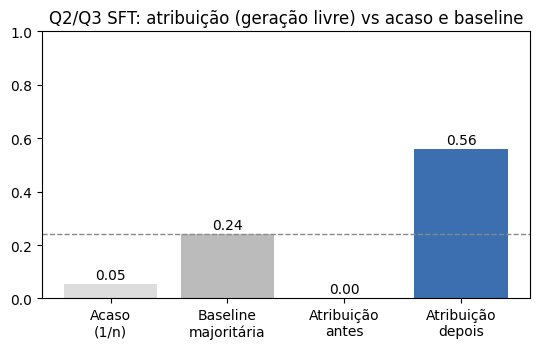

In [10]:
import matplotlib.pyplot as plt
labs = ["Acaso\n(1/n)", "Baseline\nmajoritária", "Atribuição\nantes", "Atribuição\ndepois"]
vals = [_ACASO, maj_baseline, gen_antes, gen_depois]      # métrica principal = geração livre
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.bar(labs, vals, color=["#ddd", "#bbb", "#9cc0e8", "#3b6fb0"])
ax.axhline(maj_baseline, ls="--", lw=1, color="#888")
ax.set_ylim(0, 1); ax.set_title("Q2/Q3 SFT: atribuição (geração livre) vs acaso e baseline")
for i, v in enumerate(vals): ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout(); plt.show()